## 1. What this notebook computes

The quanta of dirac16complex interact through the contact term
$U = \frac\lambda2 S^2$ of the Lagrangian, $S = \bar\Psi\Psi$. The Kohn-Sham
model needs the energy of this interaction in a Kohn-Sham state (a Slater
determinant or a thermal mixture of orbitals) as a function of the densities.
This notebook derives it exactly, with the author's gamma matrices:

- the plane waves of the good sector in flat space, their energies $\pm E$ and
  the projector on the positive ones;
- why every occupation that is symmetric under $\mathbf p \to -\mathbf p$ has
  the one-body matrix $\rho = (nB + SC)/16$ (figure 1);
- the Hartree-Fock energy: Hartree $\frac\lambda2S^2$ plus the EXACT LOCAL
  EXCHANGE $-\frac{\lambda}{32}(n^2 + S^2)$, and the ratio $-1/8$ of a filled
  level at rest (figure 2);
- the Kohn-Sham potentials $M_{\rm eff} = m + \frac{15}{16}\lambda S$ and
  $v_v = -\frac{\lambda}{16}n$;
- the exact Fock exchange of a closed-shell slab state, $-\frac{\lambda}{32}
  (n^2 + S^2 - Q^2)$, which the uniform-gas formula misses by
  $+\frac{\lambda}{32}Q^2$ (figure 3);
- the densities and potentials of the eight brane zero modes (the state
  $N = 8$), which reproduce the Revision calibration of the coupling, and why the
  exact Fock exchange of that state is exactly zero (figure 4).

It prints a PASS line for every check (16 in all) and saves four figures.

## 2. How to run this notebook

**Step 1. What this notebook does and what it needs.**

Notebook 14d (The exact local exchange of the contact interaction and the Kohn-Sham
potentials) is the file `Revision/textbook/notebooks/14d_local_exchange.ipynb` of the
repository Dirac_claude. It derives with exact algebra on the author's gamma matrices the
Hartree-Fock energy of the contact interaction U = (lambda/2) S^2 of dirac16complex in
Kohn-Sham states: the positive-energy projector of the flat good-sector plane waves, the
cancellation between the momenta p and -p that makes the one-body matrix of every
symmetric occupation equal to (nB + SC)/16, the bookkeeping of Wick's rule checked term
by term, the exact local exchange -(lambda/32)(n^2 + S^2), the filled-shell ratio -1/8,
the Kohn-Sham potentials M_eff = m + (15/16) lambda S and v_v = -lambda n/16, and the
exact Fock exchange of the closed-shell slab, which differs by +(lambda/32) Q^2; it then
computes the densities of the eight brane zero modes and reproduces the Revision
calibration of the coupling for N = 8 and the vanishing exact-Fock energy of that state,
with four teaching figures. It needs a computer with Windows 11, macOS or Linux, an
internet connection for the installation, the program Git, and Python 3.12 or newer (the
notebooks were built with Python 3.14.5) with these packages at exactly these versions:
numpy 2.4.6, sympy 1.14.0, mpmath 1.3.0, matplotlib 3.11.0, jupyterlab 4.4.10, nbformat
5.10.4, nbclient 0.10.2, ipykernel 7.1.0 and nbconvert 7.16.6. The notebook itself
imports numpy, sympy and matplotlib; the other packages run Jupyter, the program that
shows and runs notebooks. It does not need Rust.

**Step 2. Install Git and Python (once per computer).**

A terminal is the window in which you type commands: on Windows the app Windows
PowerShell (or Terminal), on macOS the app Terminal (it runs the shell zsh), on Linux any
terminal (it runs the shell bash). Type every command of this section into a terminal
exactly as printed, one line at a time, and press Enter after each line.

Windows: download Git from https://git-scm.com/download/win and install it with the
default choices. Download Python from https://www.python.org/downloads/ and run the
installer; in its first window tick the box "Add python.exe to PATH" before you click
"Install Now".

macOS: download Python from https://www.python.org/downloads/ and run the installer. Then
open the app Terminal and run this command, which installs Git and the compiler tools:

macOS (zsh):

    xcode-select --install

Linux (Debian or Ubuntu; other distributions have packages of the same names): run these
two commands:

Linux (bash):

    sudo apt update
    sudo apt install git python3 python3-venv

Then close the terminal and open a NEW one (a terminal opened before the installation
does not know the new programs), and check the version of Python; it must print 3.12 or a
higher number:

Windows (PowerShell):

    py -3 --version

macOS (zsh) and Linux (bash):

    python3 --version

If an older Linux prints a lower number (Ubuntu 22.04 has Python 3.10), install Python
3.12 with the following three commands, and in Step 3 type `python3.12` instead of
`python3` in the command that creates the environment:

Linux (bash), only when the version is too low:

    sudo add-apt-repository ppa:deadsnakes/ppa
    sudo apt update
    sudo apt install python3.12 python3.12-venv

**Step 3. Get the repository and install the packages (once per computer).**

The commands below download the repository (a few hundred megabytes; the folder then
needs up to about 1 GB of disk space) into the folder Dirac_claude inside your home
folder, create a private Python environment in the folder dirac-book-env inside your home
folder (a private environment is a folder with its own copy of Python and of the
packages, so that nothing else on your computer is changed), activate it (from then on
the commands `python` and `jupyter` typed in this terminal are those of the environment,
and the prompt starts with (dirac-book-env)), and install the packages at the pinned
versions (this downloads about 90 MB and takes a few minutes; the environment takes about
400 MB of disk space). If you have done this step before, for this or for another
notebook, skip it and go to Step 4; to get the newest version of the repository, run `git
pull` in the repository folder after Step 4.

Windows (PowerShell):

    cd $HOME
    git clone https://github.com/once-ere/Dirac_claude.git
    py -3 -m venv "$HOME\dirac-book-env"
    Set-ExecutionPolicy -ExecutionPolicy RemoteSigned -Scope Process -Force
    & "$HOME\dirac-book-env\Scripts\Activate.ps1"
    python -m pip install --upgrade pip
    python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
    python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
    python -m pip install ipykernel==7.1.0 nbconvert==7.16.6

The line with `Set-ExecutionPolicy` allows PowerShell to run the activation script in
this one window only; it changes nothing permanently.

macOS (zsh):

    cd ~
    git clone https://github.com/once-ere/Dirac_claude.git
    python3 -m venv ~/dirac-book-env
    source ~/dirac-book-env/bin/activate
    python -m pip install --upgrade pip
    python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
    python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
    python -m pip install ipykernel==7.1.0 nbconvert==7.16.6

Linux (bash):

    cd ~
    git clone https://github.com/once-ere/Dirac_claude.git
    python3 -m venv ~/dirac-book-env
    source ~/dirac-book-env/bin/activate
    python -m pip install --upgrade pip
    python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
    python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
    python -m pip install ipykernel==7.1.0 nbconvert==7.16.6

**Step 4. In every new terminal: activate the environment and go into the repository
folder.**

Every later step starts in the repository folder with the environment active. Run these
lines whenever you open a new terminal (they do no harm if the environment is already
active):

Windows (PowerShell):

    Set-ExecutionPolicy -ExecutionPolicy RemoteSigned -Scope Process -Force
    & "$HOME\dirac-book-env\Scripts\Activate.ps1"
    cd "$HOME\Dirac_claude"

macOS (zsh) and Linux (bash):

    source ~/dirac-book-env/bin/activate
    cd ~/Dirac_claude

**Step 5. Run the notebook in JupyterLab.**

In the repository folder, with the environment active, run these two lines (the first one
goes into the folder of the notebooks):

Windows, macOS and Linux:

    cd Revision/textbook/notebooks
    jupyter lab 14d_local_exchange.ipynb

JupyterLab opens in your web browser and shows the notebook (if no browser window opens,
copy the address that starts with `http://localhost:8888/lab` from the terminal into the
address bar of your browser). The name at the top right of the notebook must read Python
3 (ipykernel). Choose the menu Run > Run All Cells. While a cell runs, the label to its
left shows `[*]`; when it has finished, the label shows a number. The notebook has
finished when the last code cell shows a number; this takes about 30 seconds on a typical
laptop. Scroll to the end and compare the last printed lines with the lines in the step
"What the notebook writes and what you must see" below. To keep the results, save the
notebook (menu File > Save Notebook). To stop JupyterLab, choose the menu File > Shut
Down, or press Ctrl+C twice in the terminal.

**Step 6. Or run the notebook without a browser (headless).**

In the repository folder, with the environment active, run:

Windows, macOS and Linux:

    cd Revision/textbook/notebooks
    jupyter nbconvert --to notebook --execute --inplace 14d_local_exchange.ipynb

This runs every cell from the top to the bottom and saves the results into the notebook
file. A failed check stops it with an error message that contains AssertionError and the
name of the check. If the command ends with a line that starts with `[NbConvertApp]
Writing` and shows no error, every check passed; open the notebook with `jupyter lab
14d_local_exchange.ipynb` (in the same folder, without running the cells again) to read
the printed lines and see the figures.

**Step 7. What the notebook writes and what you must see.**

The notebook writes (or overwrites) these files:

- `Revision/textbook/figures/14d.captions.json`
- `Revision/textbook/figures/14d_1_pair_average.png`
- `Revision/textbook/figures/14d_2_energy_densities.png`
- `Revision/textbook/figures/14d_3_exact_fock_ratio.png`
- `Revision/textbook/figures/14d_4_zero_mode_state.png`

It changes no other file of the repository; running it headless or saving it in
JupyterLab also rewrites the notebook file itself. It does not use the internet while it
runs. The files it writes are the same files that are stored in the repository (on
another computer a figure may differ in a few bytes, which is harmless). To get the
stored versions back, run this command in the repository folder (it also undoes every
change you made yourself in the folder Revision/textbook):

Windows, macOS and Linux:

    git checkout -- Revision/textbook

Every check of the notebook prints a line that starts with PASS. At the end of the
notebook (the output of its last code cell) you must see exactly these lines:

    PASS all four figure files of this notebook exist
    ALL 16 CHECKS PASSED (notebook 14d)

and the notebook must show 4 figures below the cells that draw them.

**Step 8. If something goes wrong.**

- "ModuleNotFoundError: No module named ..." in the notebook: JupyterLab was started
  without the environment. Stop it (menu File > Shut Down), do Step 4, and start it
  again. If the error remains, another Python installation has registered its own kernel
  called python3; with the environment active, run the following command and start
  JupyterLab again:

      python -m ipykernel install --user --name python3

- "FileNotFoundError: The repository folder was not found": the notebook was opened from
  a copy outside the repository. Open the file
  `Revision/textbook/notebooks/14d_local_exchange.ipynb` inside the folder Dirac_claude.
- "fatal: destination path 'Dirac_claude' already exists" in Step 3: the repository was
  downloaded before; skip the line with `git clone`.
- Windows: "running scripts is disabled on this system": run the line with
  `Set-ExecutionPolicy` and then the activation line again. "py is not recognized": use
  `python` instead of `py -3`; "python is not recognized": install Python again and tick
  "Add python.exe to PATH".
- Linux: "ensurepip is not available" when the environment is created: run `sudo apt
  install python3-venv` and repeat Step 3.
- "jupyter is not recognized" or "command not found: jupyter": the environment is not
  active; do Step 4 (or type `python -m jupyter` instead of `jupyter`).
- Windows: the headless run prints a RuntimeWarning that mentions the "Proactor event
  loop" and zmq: this is a message of the package pyzmq, not an error; the run continues
  normally.
- A red box with "Matplotlib is building the font cache; this may take a moment." in the
  first run after the installation: this is a message, not an error; the run continues
  and the message does not come again.
- An AssertionError names a check that failed: choose the menu Kernel > Restart Kernel
  and Run All Cells; if it fails again, install the packages again with the pip commands
  of Step 3, because a different package version can change the last digits of a result.

The first code cell below (the set-up cell) repeats these instructions as comments; then
it imports the packages, finds the repository folder and defines the helpers
`save_figure` (saves a figure and shows it), `check` (stops with an AssertionError when a
check fails, prints a PASS line when it passes), `report` (prints a key number as a
RESULT line) and `all_checks_passed` (prints the last line).

In [1]:
# HOW TO RUN NOTEBOOK 14d (the complete instructions)
#
# STEP 1. WHAT THIS NOTEBOOK DOES AND WHAT IT NEEDS.
#
# Notebook 14d (The exact local exchange of the contact interaction and the Kohn-Sham
# potentials) is the file Revision/textbook/notebooks/14d_local_exchange.ipynb of the
# repository Dirac_claude. It derives with exact algebra on the author's gamma matrices
# the Hartree-Fock energy of the contact interaction U = (lambda/2) S^2 of dirac16complex
# in Kohn-Sham states: the positive-energy projector of the flat good-sector plane waves,
# the cancellation between the momenta p and -p that makes the one-body matrix of every
# symmetric occupation equal to (nB + SC)/16, the bookkeeping of Wick's rule checked term
# by term, the exact local exchange -(lambda/32)(n^2 + S^2), the filled-shell ratio -1/8,
# the Kohn-Sham potentials M_eff = m + (15/16) lambda S and v_v = -lambda n/16, and the
# exact Fock exchange of the closed-shell slab, which differs by +(lambda/32) Q^2; it
# then computes the densities of the eight brane zero modes and reproduces the Revision
# calibration of the coupling for N = 8 and the vanishing exact-Fock energy of that
# state, with four teaching figures. It needs a computer with Windows 11, macOS or Linux,
# an internet connection for the installation, the program Git, and Python 3.12 or newer
# (the notebooks were built with Python 3.14.5) with these packages at exactly these
# versions: numpy 2.4.6, sympy 1.14.0, mpmath 1.3.0, matplotlib 3.11.0, jupyterlab
# 4.4.10, nbformat 5.10.4, nbclient 0.10.2, ipykernel 7.1.0 and nbconvert 7.16.6. The
# notebook itself imports numpy, sympy and matplotlib; the other packages run Jupyter,
# the program that shows and runs notebooks. It does not need Rust.
#
# STEP 2. INSTALL GIT AND PYTHON (ONCE PER COMPUTER).
#
# A terminal is the window in which you type commands: on Windows the app Windows
# PowerShell (or Terminal), on macOS the app Terminal (it runs the shell zsh), on Linux
# any terminal (it runs the shell bash). Type every command of this section into a
# terminal exactly as printed, one line at a time, and press Enter after each line.
#
# Windows: download Git from https://git-scm.com/download/win and install it with the
# default choices. Download Python from https://www.python.org/downloads/ and run the
# installer; in its first window tick the box "Add python.exe to PATH" before you click
# "Install Now".
#
# macOS: download Python from https://www.python.org/downloads/ and run the installer.
# Then open the app Terminal and run this command, which installs Git and the compiler
# tools:
#
# macOS (zsh):
#     xcode-select --install
#
# Linux (Debian or Ubuntu; other distributions have packages of the same names): run
# these two commands:
#
# Linux (bash):
#     sudo apt update
#     sudo apt install git python3 python3-venv
#
# Then close the terminal and open a NEW one (a terminal opened before the installation
# does not know the new programs), and check the version of Python; it must print 3.12 or
# a higher number:
#
# Windows (PowerShell):
#     py -3 --version
#
# macOS (zsh) and Linux (bash):
#     python3 --version
#
# If an older Linux prints a lower number (Ubuntu 22.04 has Python 3.10), install Python
# 3.12 with the following three commands, and in Step 3 type python3.12 instead of
# python3 in the command that creates the environment:
#
# Linux (bash), only when the version is too low:
#     sudo add-apt-repository ppa:deadsnakes/ppa
#     sudo apt update
#     sudo apt install python3.12 python3.12-venv
#
# STEP 3. GET THE REPOSITORY AND INSTALL THE PACKAGES (ONCE PER COMPUTER).
#
# The commands below download the repository (a few hundred megabytes; the folder then
# needs up to about 1 GB of disk space) into the folder Dirac_claude inside your home
# folder, create a private Python environment in the folder dirac-book-env inside your
# home folder (a private environment is a folder with its own copy of Python and of the
# packages, so that nothing else on your computer is changed), activate it (from then on
# the commands python and jupyter typed in this terminal are those of the environment,
# and the prompt starts with (dirac-book-env)), and install the packages at the pinned
# versions (this downloads about 90 MB and takes a few minutes; the environment takes
# about 400 MB of disk space). If you have done this step before, for this or for another
# notebook, skip it and go to Step 4; to get the newest version of the repository, run
# git pull in the repository folder after Step 4.
#
# Windows (PowerShell):
#     cd $HOME
#     git clone https://github.com/once-ere/Dirac_claude.git
#     py -3 -m venv "$HOME\dirac-book-env"
#     Set-ExecutionPolicy -ExecutionPolicy RemoteSigned -Scope Process -Force
#     & "$HOME\dirac-book-env\Scripts\Activate.ps1"
#     python -m pip install --upgrade pip
#     python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
#     python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
#     python -m pip install ipykernel==7.1.0 nbconvert==7.16.6
#
# The line with Set-ExecutionPolicy allows PowerShell to run the activation script in
# this one window only; it changes nothing permanently.
#
# macOS (zsh):
#     cd ~
#     git clone https://github.com/once-ere/Dirac_claude.git
#     python3 -m venv ~/dirac-book-env
#     source ~/dirac-book-env/bin/activate
#     python -m pip install --upgrade pip
#     python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
#     python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
#     python -m pip install ipykernel==7.1.0 nbconvert==7.16.6
#
# Linux (bash):
#     cd ~
#     git clone https://github.com/once-ere/Dirac_claude.git
#     python3 -m venv ~/dirac-book-env
#     source ~/dirac-book-env/bin/activate
#     python -m pip install --upgrade pip
#     python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
#     python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
#     python -m pip install ipykernel==7.1.0 nbconvert==7.16.6
#
# STEP 4. IN EVERY NEW TERMINAL: ACTIVATE THE ENVIRONMENT AND GO INTO THE REPOSITORY
# FOLDER.
#
# Every later step starts in the repository folder with the environment active. Run these
# lines whenever you open a new terminal (they do no harm if the environment is already
# active):
#
# Windows (PowerShell):
#     Set-ExecutionPolicy -ExecutionPolicy RemoteSigned -Scope Process -Force
#     & "$HOME\dirac-book-env\Scripts\Activate.ps1"
#     cd "$HOME\Dirac_claude"
#
# macOS (zsh) and Linux (bash):
#     source ~/dirac-book-env/bin/activate
#     cd ~/Dirac_claude
#
# STEP 5. RUN THE NOTEBOOK IN JUPYTERLAB.
#
# In the repository folder, with the environment active, run these two lines (the first
# one goes into the folder of the notebooks):
#
# Windows, macOS and Linux:
#     cd Revision/textbook/notebooks
#     jupyter lab 14d_local_exchange.ipynb
#
# JupyterLab opens in your web browser and shows the notebook (if no browser window
# opens, copy the address that starts with http://localhost:8888/lab from the terminal
# into the address bar of your browser). The name at the top right of the notebook must
# read Python 3 (ipykernel). Choose the menu Run > Run All Cells. While a cell runs, the
# label to its left shows [*]; when it has finished, the label shows a number. The
# notebook has finished when the last code cell shows a number; this takes about 30
# seconds on a typical laptop. Scroll to the end and compare the last printed lines with
# the lines in the step "What the notebook writes and what you must see" below. To keep
# the results, save the notebook (menu File > Save Notebook). To stop JupyterLab, choose
# the menu File > Shut Down, or press Ctrl+C twice in the terminal.
#
# STEP 6. OR RUN THE NOTEBOOK WITHOUT A BROWSER (HEADLESS).
#
# In the repository folder, with the environment active, run:
#
# Windows, macOS and Linux:
#     cd Revision/textbook/notebooks
#     jupyter nbconvert --to notebook --execute --inplace 14d_local_exchange.ipynb
#
# This runs every cell from the top to the bottom and saves the results into the notebook
# file. A failed check stops it with an error message that contains AssertionError and
# the name of the check. If the command ends with a line that starts with [NbConvertApp]
# Writing and shows no error, every check passed; open the notebook with jupyter lab
# 14d_local_exchange.ipynb (in the same folder, without running the cells again) to read
# the printed lines and see the figures.
#
# STEP 7. WHAT THE NOTEBOOK WRITES AND WHAT YOU MUST SEE.
#
# The notebook writes (or overwrites) these files:
#
# - Revision/textbook/figures/14d.captions.json
# - Revision/textbook/figures/14d_1_pair_average.png
# - Revision/textbook/figures/14d_2_energy_densities.png
# - Revision/textbook/figures/14d_3_exact_fock_ratio.png
# - Revision/textbook/figures/14d_4_zero_mode_state.png
#
# It changes no other file of the repository; running it headless or saving it in
# JupyterLab also rewrites the notebook file itself. It does not use the internet while
# it runs. The files it writes are the same files that are stored in the repository (on
# another computer a figure may differ in a few bytes, which is harmless). To get the
# stored versions back, run this command in the repository folder (it also undoes every
# change you made yourself in the folder Revision/textbook):
#
# Windows, macOS and Linux:
#     git checkout -- Revision/textbook
#
# Every check of the notebook prints a line that starts with PASS. At the end of the
# notebook (the output of its last code cell) you must see exactly these lines:
#
#     PASS all four figure files of this notebook exist
#     ALL 16 CHECKS PASSED (notebook 14d)
#
# and the notebook must show 4 figures below the cells that draw them.
#
# STEP 8. IF SOMETHING GOES WRONG.
#
# - "ModuleNotFoundError: No module named ..." in the notebook: JupyterLab was started
#   without the environment. Stop it (menu File > Shut Down), do Step 4, and start it
#   again. If the error remains, another Python installation has registered its own
#   kernel called python3; with the environment active, run the following command and
#   start JupyterLab again:
#     python -m ipykernel install --user --name python3
# - "FileNotFoundError: The repository folder was not found": the notebook was opened
#   from a copy outside the repository. Open the file
#   Revision/textbook/notebooks/14d_local_exchange.ipynb inside the folder Dirac_claude.
# - "fatal: destination path 'Dirac_claude' already exists" in Step 3: the repository was
#   downloaded before; skip the line with git clone.
# - Windows: "running scripts is disabled on this system": run the line with
#   Set-ExecutionPolicy and then the activation line again. "py is not recognized": use
#   python instead of py -3; "python is not recognized": install Python again and tick
#   "Add python.exe to PATH".
# - Linux: "ensurepip is not available" when the environment is created: run sudo apt
#   install python3-venv and repeat Step 3.
# - "jupyter is not recognized" or "command not found: jupyter": the environment is not
#   active; do Step 4 (or type python -m jupyter instead of jupyter).
# - Windows: the headless run prints a RuntimeWarning that mentions the "Proactor event
#   loop" and zmq: this is a message of the package pyzmq, not an error; the run
#   continues normally.
# - A red box with "Matplotlib is building the font cache; this may take a moment." in
#   the first run after the installation: this is a message, not an error; the run
#   continues and the message does not come again.
# - An AssertionError names a check that failed: choose the menu Kernel > Restart Kernel
#   and Run All Cells; if it fails again, install the packages again with the pip
#   commands of Step 3, because a different package version can change the last digits of
#   a result.
#
# ---------------------------------------------------------------------------------------
# =======================================================================================
# THE SET-UP (the same in every notebook of this book; it computes no physics)
# =======================================================================================
import json  # reads and writes JSON files (text files that hold names and numbers)
import os  # reads the environment variable TEXTBOOK_OUTPUT_ROOT (explained below)
import textwrap  # breaks long printed text into lines of at most 89 characters
from pathlib import Path  # file and folder paths that work on Windows, macOS and Linux

import matplotlib  # the plotting package
import matplotlib.pyplot as plt  # its drawing functions, called plt by convention
from IPython.display import Image, display  # shows a saved picture below a cell

NOTEBOOK_ID = "14d"  # this notebook: chapter 14, example d


def find_repository_root():
    """Return the repository folder (Dirac_claude).

    Jupyter runs a notebook in the folder that holds it.  Starting there, go up one
    folder at a time until a folder contains Revision/textbook/requirements.txt (the
    list of the book's packages); that folder is the repository."""
    here = Path.cwd().resolve()  # the folder in which this notebook runs
    for folder in [here, *here.parents]:  # this folder, its parent, its grandparent ...
        if (folder / "Revision" / "textbook" / "requirements.txt").is_file():
            return folder
    raise FileNotFoundError(
        "The repository folder was not found: open this notebook inside the folder "
        "Revision/textbook/notebooks of the repository Dirac_claude")


# The repository folder.  It is never printed: it differs from computer to computer,
# and the printed output of a notebook must not.
REPO = find_repository_root()
# Every file is WRITTEN below OUTPUT_ROOT.  OUTPUT_ROOT is the repository folder unless
# the environment variable TEXTBOOK_OUTPUT_ROOT names another folder; the book's
# checking tool sets it, so that a check run writes into a scratch folder instead.
OUTPUT_ROOT = Path(os.environ.get("TEXTBOOK_OUTPUT_ROOT", str(REPO)))


def repository_file(relative):
    """The path of the repository file relative, for READING (a Revision record)."""
    return REPO / relative


def output_file(relative):
    """The path at which to WRITE the repository file relative (its folder is made)."""
    path = OUTPUT_ROOT / relative
    path.parent.mkdir(parents=True, exist_ok=True)
    return path


def say(text):
    """Print text in lines of at most 89 characters (the width of a page of the book)."""
    print(textwrap.fill(str(text), width=89, subsequent_indent="    "))


matplotlib.rcdefaults()  # ignore personal matplotlib settings: same figures everywhere
plt.rcParams.update({"figure.figsize": (7.0, 4.2), "font.size": 10.0,
                     "axes.grid": True, "grid.alpha": 0.3})

FIGURE_FOLDER = "Revision/textbook/figures"  # where the figures are saved
CAPTION_FILE = f"{FIGURE_FOLDER}/{NOTEBOOK_ID}.captions.json"  # their captions
FIGURE_NUMBERS = {}  # figure name -> its number k (file name <id>_<k>_<name>.png)
CAPTIONS = {}  # figure file name -> caption, written to CAPTION_FILE after every figure
# Start with an empty captions file ({} is an empty JSON dictionary); save_figure fills
# it.  newline="\n" writes the same line ends on Windows, macOS and Linux.
output_file(CAPTION_FILE).write_text("{}\n", encoding="utf-8", newline="\n")


def save_figure(fig, name, caption):
    """Save the figure fig as Revision/textbook/figures/<id>_<k>_<name>.png, record its
    caption in CAPTION_FILE, show the saved picture below the cell and close the figure.
    k counts the figures of the notebook 1, 2, 3, ...; a cell run again keeps its k."""
    number = FIGURE_NUMBERS.setdefault(name, len(FIGURE_NUMBERS) + 1)
    file_name = f"{NOTEBOOK_ID}_{number}_{name}.png"
    relative = f"{FIGURE_FOLDER}/{file_name}"
    # dpi=150: 150 dots per inch.  bbox_inches="tight": cut away the empty margin.
    # metadata={"Software": None}: no program name is stored in the PNG file, so that
    # every run writes exactly the same bytes.
    fig.savefig(output_file(relative), dpi=150, bbox_inches="tight",
                metadata={"Software": None})
    plt.close(fig)  # forget the figure, so that Jupyter does not draw it a second time
    CAPTIONS[file_name] = caption
    output_file(CAPTION_FILE).write_text(
        json.dumps(CAPTIONS, indent=1, sort_keys=True) + "\n", encoding="utf-8",
        newline="\n")
    display(Image(filename=str(output_file(relative))),
            metadata={"textbook_figure": file_name})  # the saved picture itself
    say(f"Figure {NOTEBOOK_ID}.{number} saved as {relative}")


PASSED = []  # the names of the checks that passed, in order


def check(condition, name, record=None):
    """A check.  If condition is False, stop with an AssertionError that names the
    check (an if statement is used instead of assert, because python -O would skip an
    assert).  Otherwise print "PASS <name>" and, when the check reproduces a Revision
    record, a second line naming the record file and its check."""
    if not condition:
        raise AssertionError(f"check failed: {name}")
    PASSED.append(name)
    say(f"PASS {name}")
    if record is not None:
        say(f"     reproduces {record}")


def report(label, value, unit=""):
    """Print a key number as a line "RESULT <label> = <value> <unit>"."""
    say(f"RESULT {label} = {value}" + (f" {unit}" if unit else ""))


def all_checks_passed():
    """Print the last line of the notebook: how many checks passed."""
    print(f"ALL {len(PASSED)} CHECKS PASSED (notebook {NOTEBOOK_ID})")


say(f"Set-up of notebook {NOTEBOOK_ID} complete: repository folder found, helpers "
    "defined.")

Set-up of notebook 14d complete: repository folder found, helpers defined.


## 3. The words used in this notebook

- **Contact interaction**: the term $U(S) = \frac\lambda2S^2$ of the
  Lagrangian; $\lambda > 0$ is repulsive. $\lambda$ has the dimension
  mass$^{-6}$.
- **Density**: an expectation value per unit volume. Number density
  $n = \langle\Psi^\dagger B\Psi\rangle$; scalar density
  $S = \langle\bar\Psi\Psi\rangle = \langle\Psi^\dagger C\Psi\rangle$; the
  density $Q = \langle\Psi^\dagger B\gamma^{(x_8)}\Psi\rangle$. PROPER densities
  are per proper 7-volume.
- **Expectation-value rule**: for one quantum in the mode $u$,
  $\langle\Psi^\dagger X\Psi\rangle = u^\dagger BXu$; for many,
  $\langle\Psi^\dagger X\Psi\rangle = \mathrm{Tr}(X\rho)$ with the one-body
  matrix $\rho = \sum_{\rm occupied} f\,uu^\dagger B$ ($f$ the occupation).
- **Trace** $\mathrm{Tr}\,X$: the sum of the diagonal entries; $\mathrm{Tr}(XY)
  = \mathrm{Tr}(YX)$.
- **Normal ordering** $:\;:$: the operators of the free sea are reordered so
  that the vacuum has zero energy; it removes the infinite sea contributions.
- **Quasi-free state, Wick's rule**: a Slater determinant or a thermal state of
  independent quanta; the expectation of four field operators is a sum of
  products of two-operator expectations (a "direct" and an "exchange" term).
- **Hartree term, exchange term**: the direct and the exchange part of the
  interaction energy. **Hartree-Fock**: keeping both, for a quasi-free state.
- **Kohn-Sham potential**: the derivative of the interaction energy density with
  respect to a density; it enters the one-quantum equation.
- **Uniform gas**: quanta in flat space, the same in every place.
- **Closed-shell slab**: the Kohn-Sham states of the model, uniform along 3-space
  but not along the hidden coordinate $y$, with complete lattice shells filled.
- **Commutant**: all matrices that commute with a given set of matrices.
- **Zero modes, $N = 8$**: the eight brane-bound orbitals at zero 3-momentum,
  $\chi = (a, 0)$ with $a \propto e^{My}$; filling them gives the state $N = 8$.

## 4. The physical and mathematical situation

The Revision theory (`Revision/kohn_sham/ks-theory.json`, section `exchange`)
builds the Kohn-Sham functional of dirac16complex from the Hartree-Fock energy of
the uniform good-sector gas, which turns out to be LOCAL (a function of the
densities at one point) at every temperature. The steps, each exact:

1. In flat space a plane wave $e^{-i\varepsilon x_4 + i\mathbf p\cdot\mathbf x}$
   of the good sector solves $h_{\mathbf p}u = \varepsilon u$ with
   $h_{\mathbf p} = M(-i\gamma^{(x_4)}) - p_a\gamma^{(x_4)}\gamma^{(a)}$, the sum
   over the four space-like directions $x_1, x_2, x_3, x_8$.
2. $h_{\mathbf p}^2 = (M^2 + p^2)\,1$: the energies are $\pm E$,
   $E = \sqrt{M^2 + p^2}$, each 8 times.
3. The interaction energy needs $\langle{:}S^2{:}\rangle$, which Wick's rule
   turns into $(\mathrm{Tr}\,C\rho)^2 - \mathrm{Tr}(C\rho C\rho)$.
4. For symmetric occupations $\rho = (nB + SC)/16$, and the second trace is
   $(n^2 + S^2)/16$.

Status: every formula here is PROVED (exact; verified twice in the Revision
record). The use of the uniform-gas exchange for the slab states of the model is
the canonical functional of the Revision theory (an approximation: no
correlation energy); the exact Fock exchange of the slab is a DIAGNOSTIC.

## 5. The gamma matrices, B and C

The next cell reads the author's gamma matrices from the Revision record
`Revision/algebra/gammas.json` (`g1` is $\gamma^{(x_1)}$, ..., `g8` is
$\gamma^{(x_8)}$), builds $C = \gamma^{(x_8)}\gamma^{(x_1)}\gamma^{(x_2)}
\gamma^{(x_3)}$ and $B = -iC\gamma^{(x_4)}$, and checks the facts used below:
$B$ and $C$ square to 1, $\mathrm{Tr}\,B^2 = \mathrm{Tr}\,C^2 = 16$,
$\mathrm{Tr}\,BC = 0$, $CBC = B$, and $(-i\gamma^{(x_4)})B = C$. It also defines
`record_check`, which reads the verdict of a named check from the two Revision
theory reports.

In [2]:
import math  # exp, sqrt, log10 of single numbers

import numpy as np  # floating-point arrays
import sympy as sp  # exact algebra with symbols

PY_REPORT = "Revision/kohn_sham/reports/ks-theory-python.json"
WL_REPORT = "Revision/kohn_sham/reports/ks-theory-wolfram.json"


def record_check(name):
    """PASS in the sympy record and, if the WolframScript record has a check of
    that name, PASS there too."""
    verdicts = []
    for report_file in (PY_REPORT, WL_REPORT):
        data = json.loads(repository_file(report_file).read_text(encoding="utf-8"))
        found = [c["verdict"] for c in data["checks"] if c["name"] == name]
        verdicts.append(found[0] if found else "absent")
    return verdicts[0] == "PASS" and verdicts[1] in ("PASS", "absent")


fixture = json.loads(repository_file("Revision/algebra/gammas.json")
                     .read_text(encoding="utf-8"))
g = [sp.Matrix(m) for m in fixture["gamma"]]
g1, g2, g3, g4, g5, g6, g7, g8 = g
I16, Z16 = sp.eye(16), sp.zeros(16)
C = g8 * g1 * g2 * g3
B = -sp.I * C * g4
facts_ok = (B * B == I16 and C * C == I16 and (B * B).trace() == 16
            and (C * C).trace() == 16 and (B * C).trace() == 0 and C * B * C == B
            and (-sp.I * g4) * B == C)
check(facts_ok, "B^2 = C^2 = 1, Tr B^2 = Tr C^2 = 16, Tr BC = 0, CBC = B, (-i g4) B = C")

PASS B^2 = C^2 = 1, Tr B^2 = Tr C^2 = 16, Tr BC = 0, CBC = B, (-i g4) B = C


## 6. The plane waves of the good sector and their projector

The four space-like directions are $x_1, x_2, x_3, x_8$; their gammas square to
$+1$, and $\gamma^{(x_4)}$ squares to $-1$. Line by line:

1. $h_{\mathbf p} = M(-i\gamma^{(x_4)}) - \sum_a p_a\gamma^{(x_4)}\gamma^{(a)}$.
2. Squaring: $(-i\gamma^{(x_4)})^2 = -(\gamma^{(x_4)})^2 = 1$;
   $(\gamma^{(x_4)}\gamma^{(a)})^2 = -(\gamma^{(x_4)})^2(\gamma^{(a)})^2 = 1$;
   all mixed products anticommute and cancel in pairs. So
   $h_{\mathbf p}^2 = (M^2 + p_1^2 + p_2^2 + p_3^2 + p_8^2)\,1 = E^2\,1$.
3. Hence $G_{\mathbf p} = \frac12(1 + h_{\mathbf p}/E)$ satisfies
   $G_{\mathbf p}^2 = G_{\mathbf p}$: it projects on the energy $+E$; its trace
   is 8 because $h_{\mathbf p}$ is traceless: eight positive-energy modes.

The next cell checks the three lines with sympy.

In [3]:
M = sp.symbols("M", positive=True)  # the mass
p1, p2, p3, p8 = sp.symbols("p1 p2 p3 p8", real=True)  # the momentum
E = sp.symbols("E", positive=True)  # stands for sqrt(M^2 + p^2)
h_p = M * (-sp.I * g4) - (p1 * g4 * g1 + p2 * g4 * g2 + p3 * g4 * g3 + p8 * g4 * g8)
E_squared = M ** 2 + p1 ** 2 + p2 ** 2 + p3 ** 2 + p8 ** 2
square_ok = (h_p * h_p - E_squared * I16).applyfunc(sp.expand).is_zero_matrix
G_p = (I16 + h_p / E) / 2  # the projector on the positive energy
projector_ok = ((G_p * G_p - G_p).subs(E, sp.sqrt(E_squared))
                .applyfunc(sp.simplify).is_zero_matrix
                and G_p.H == G_p and sp.simplify(G_p.trace()) == 8)
check(square_ok and projector_ok and record_check("gas_mode_projector"),
      "h_p^2 = (M^2 + p^2) 1 and G_p = (1 + h_p/E)/2 is a projector of rank 8",
      record=f"{PY_REPORT}, check gas_mode_projector")

PASS h_p^2 = (M^2 + p^2) 1 and G_p = (1 + h_p/E)/2 is a projector of rank 8
     reproduces Revision/kohn_sham/reports/ks-theory-python.json, check
    gas_mode_projector


## 7. Why every symmetric occupation gives rho = (nB + SC)/16

The one-body matrix of the eight positive-energy modes at momentum $\mathbf p$
is $G_{\mathbf p}B$. Split it into a part that does not depend on the direction
of $\mathbf p$ and a part that is linear in $\mathbf p$:

$$G_{\mathbf p}B = \frac12\left(B + \frac ME(-i\gamma^{(x_4)})B\right) -
\frac1{2E}\sum_a p_a\gamma^{(x_4)}\gamma^{(a)}B .$$

The linear part changes sign under $\mathbf p \to -\mathbf p$. So if the
occupation is the same for $\mathbf p$ and $-\mathbf p$ (true for every closed
shell and for the thermal states), the linear parts cancel in pairs, and with
$(-i\gamma^{(x_4)})B = C$ what is left is $\frac12(B + \frac ME C)$. The same
holds for an average over all directions (the average of each component of a
direction over the sphere is 0). For the negative-energy modes,
$\frac12(1 - h_{\mathbf p}/E)B$, the result is $\frac12(B - \frac ME C)$. Adding
up any such occupation therefore gives a combination of $B$ and $C$ only,
$\rho = \alpha B + \beta C$; and since $\mathrm{Tr}(B\rho) = 16\alpha = n$ and
$\mathrm{Tr}(C\rho) = 16\beta = S$,

$$\rho = \frac{nB + SC}{16}.$$

The next cell checks the pair cancellation, the sphere averages of the three
components (exact integrals), both mode types and the trace formulas.

In [4]:
p_flip = {p1: -p1, p2: -p2, p3: -p3, p8: -p8}
pair_average = ((G_p * B + (G_p * B).subs(p_flip)) / 2).applyfunc(sp.simplify)
pair_ok = (pair_average - (B + M / E * C) / 2).applyfunc(sp.simplify).is_zero_matrix
th, ph = sp.symbols("vartheta varphi", real=True)  # angles on the sphere
components = [sp.sin(th) * sp.cos(ph), sp.sin(th) * sp.sin(ph), sp.cos(th)]
sphere = [sp.integrate(sp.integrate(c * sp.sin(th), (ph, 0, 2 * sp.pi)), (th, 0, sp.pi))
          / (4 * sp.pi) for c in components]  # the averages of the components
say(f"sphere averages of the three direction components: {sphere}")
check(pair_ok and sphere == [0, 0, 0] and record_check("gas_angular_average"),
      "the average over p and -p (or over all directions) is (B + (M/E) C)/2",
      record=f"{PY_REPORT}, check gas_angular_average")
h_0 = M * (-sp.I * g4)  # the p-independent part of h_p
negative_ok = (((I16 - h_0 / E) / 2) * B - (B - M / E * C) / 2).is_zero_matrix
check(negative_ok and record_check("gas_negative_energy_modes"),
      "negative-energy modes give (B - (M/E) C)/2: only B and C ever appear",
      record=f"{PY_REPORT}, check gas_negative_energy_modes")
n, S, lam = sp.symbols("n S lambda", real=True)
rho = (n * B + S * C) / 16  # the one-body matrix of a symmetric occupation
check(sp.expand((B * rho).trace()) == n and sp.expand((C * rho).trace()) == S
      and record_check("gas_densities"),
      "rho = (nB + SC)/16 has Tr(B rho) = n and Tr(C rho) = S",
      record=f"{PY_REPORT}, check gas_densities")

sphere averages of the three direction components: [0, 0, 0]
PASS the average over p and -p (or over all directions) is (B + (M/E) C)/2
     reproduces Revision/kohn_sham/reports/ks-theory-python.json, check
    gas_angular_average
PASS negative-energy modes give (B - (M/E) C)/2: only B and C ever appear
     reproduces Revision/kohn_sham/reports/ks-theory-python.json, check
    gas_negative_energy_modes
PASS rho = (nB + SC)/16 has Tr(B rho) = n and Tr(C rho) = S
     reproduces Revision/kohn_sham/reports/ks-theory-python.json, check gas_densities


The next cell draws the cancellation for $M = 1$, $\mathbf p = (1, 0, 0, 0)$
(so $E = \sqrt2$): the absolute values of the entries of the one-body matrix
$G_{\mathbf p}B$ of one momentum (left), of its average with $-\mathbf p$
(middle), which is exactly $\frac12(B + C/\sqrt2)$, and of the part linear in
$\mathbf p$ (right), which cancels between $\mathbf p$ and $-\mathbf p$.

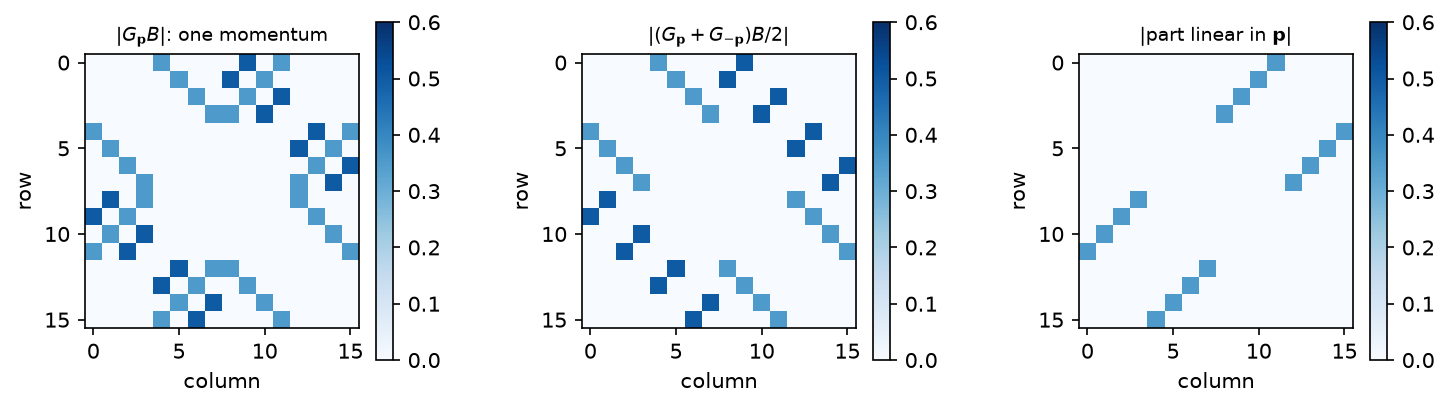

Figure 14d.1 saved as Revision/textbook/figures/14d_1_pair_average.png


In [5]:
values = {M: 1, E: sp.sqrt(2), p1: 1, p2: 0, p3: 0, p8: 0}
one_mode = np.abs(np.array((G_p * B).subs(values).evalf(), dtype=complex))
averaged = np.abs(np.array(pair_average.subs(values).evalf(), dtype=complex))
odd_part = np.abs(np.array((G_p * B - pair_average).subs(values).evalf(),
                           dtype=complex))
fig, axes = plt.subplots(1, 3, figsize=(11.5, 3.9))
fig.subplots_adjust(wspace=0.45)
titles = ["$|G_{\\mathbf{p}}B|$: one momentum",
          "$|(G_{\\mathbf{p}} + G_{-\\mathbf{p}})B/2|$",
          "$|$part linear in $\\mathbf{p}|$"]
for ax, data, title in zip(axes, (one_mode, averaged, odd_part), titles):
    image = ax.imshow(data, cmap="Blues", vmin=0.0, vmax=0.6,
                      interpolation="nearest")
    ax.set_title(title, fontsize=9)
    ax.set_xticks([0, 5, 10, 15])
    ax.set_yticks([0, 5, 10, 15])
    ax.set_xlabel("column")
    ax.set_ylabel("row")
    ax.grid(False)
    fig.colorbar(image, ax=ax, shrink=0.75)
save_figure(fig, "pair_average",
            "Absolute values of the entries (rows and columns 0 to 15, darker is "
            "larger) of the one-body matrix of the eight positive-energy plane "
            "waves for $M = 1$ and the momentum $\\mathbf{p} = (1, 0, 0, 0)$, "
            "$E = \\sqrt{2}$: left for one momentum, middle averaged with "
            "$-\\mathbf{p}$, which leaves exactly $(B + C/\\sqrt{2})/2$, a "
            "combination of $B$ and $C$ only; right the part linear in "
            "$\\mathbf{p}$, which cancels between $\\mathbf{p}$ and $-\\mathbf{p}$. "
            "Every occupation that is symmetric under $\\mathbf{p} \\to "
            "-\\mathbf{p}$ therefore has the one-body matrix $(nB + SC)/16$.")

## 8. Wick's rule for the contact term

For a quasi-free state with the two-operator expectations
$f_{AB} = \langle\Psi_A^\dagger\Psi_B\rangle = \rho_{BA}$ (the expectation-value
rule), Wick's rule gives for the normal-ordered square of
$S = \Psi^\dagger C\Psi = \sum_{AB}\Psi_A^\dagger C_{AB}\Psi_B$

$$\langle{:}S^2{:}\rangle = \sum_{ABCD}C_{AB}C_{CD}\,(f_{AB}f_{CD} -
f_{AD}f_{CB}) .$$

The first product is the DIRECT (Hartree) term, the second, with the minus sign
of the anticommuting fields, the EXCHANGE (Fock) term. In matrix language the
first sum is $(\mathrm{Tr}\,C\rho)^2$ and the second is $\mathrm{Tr}(C\rho C
\rho)$. The next cell checks this bookkeeping term by term, as the Revision
record did, for the explicit two-mode state with the mode vectors $u_1, u_2$ of
the record, and for a second two-mode state $v_1, v_2$ with less symmetry: it
adds up the $16^4$ terms of the sum (only those with nonzero $C$ entries are
kept, 256 of them) and compares with the two traces.

In [6]:
half, i_half = sp.Rational(1, 2), sp.I / 2
u1 = sp.Matrix([half, i_half, 0, 0, 0, 0, 0, 0, half, 0, 0, 0, 0, 0, -i_half, 0])
u2 = sp.Matrix([0, 0, half, 0, -half, 0, 0, 0, 0, 0, i_half, 0, 0, 0, 0, i_half])
v1 = sp.Matrix([1, 2, 0, -1, sp.I, 0, 3, 1, 0, 1, -2, sp.I, 0, 1, 1, 0]) / 4
v2 = sp.Matrix([0, 1, sp.I, 2, 1, -1, 0, 0, 1, 0, sp.I, 1, 2, 0, -1, 1]) / 4
nonzero = [(A_, B_) for A_ in range(16) for B_ in range(16) if C[A_, B_] != 0]
wick_ok = True
for name, modes in (("u1, u2 (record)", (u1, u2)), ("v1, v2", (v1, v2))):
    rho_2 = (modes[0] * modes[0].H + modes[1] * modes[1].H) * B  # one-body matrix
    f = rho_2.T  # f_AB = rho_BA
    brute = sp.simplify(sum(
        C[A_, B_] * C[C_, D_] * (f[A_, B_] * f[C_, D_] - f[A_, D_] * f[C_, B_])
        for A_, B_ in nonzero for C_, D_ in nonzero))
    direct = sp.simplify((C * rho_2).trace() ** 2)
    exchange = sp.simplify((C * rho_2 * C * rho_2).trace())
    say(f"state {name}: (Tr C rho)^2 = {direct}, Tr(C rho C rho) = {exchange}, "
        f"term-by-term sum = {brute}")
    wick_ok &= sp.simplify(brute - (direct - exchange)) == 0
check(len(nonzero) == 16 and wick_ok and record_check("hf_wick_contraction"),
      "<:S^2:> = (Tr C rho)^2 - Tr(C rho C rho), checked term by term",
      record=f"{PY_REPORT}, check hf_wick_contraction")

state u1, u2 (record): (Tr C rho)^2 = 1/4, Tr(C rho C rho) = 1/4, term-by-term sum = 0
state v1, v2: (Tr C rho)^2 = 25/64, Tr(C rho C rho) = 9/32, term-by-term sum = 7/64
PASS <:S^2:> = (Tr C rho)^2 - Tr(C rho C rho), checked term by term
     reproduces Revision/kohn_sham/reports/ks-theory-python.json, check
    hf_wick_contraction


## 9. The exact local exchange and the filled-shell ratio

With $\rho = (nB + SC)/16$ (line by line, using $CBC = B$, $C^2 = 1$,
$\mathrm{Tr}\,B^2 = \mathrm{Tr}\,C^2 = 16$, $\mathrm{Tr}\,BC = 0$):

1. $C\rho = (nCB + S)/16$.
2. $(C\rho)^2 = (n^2CBCB + nS\,CB + nS\,CB + S^2)/256 = (n^2 + 2nS\,CB +
   S^2)/256$, because $CBCB = BB = 1$.
3. $\mathrm{Tr}(C\rho C\rho) = (16n^2 + 0 + 16S^2)/256 = (n^2 + S^2)/16$.
4. The energy density is $\frac\lambda2\langle{:}S^2{:}\rangle = e_H + e_x$ with
   the Hartree term $e_H = \frac\lambda2S^2$ and the EXCHANGE
   $e_x = -\frac\lambda2\mathrm{Tr}(C\rho C\rho) = -\frac{\lambda}{32}(n^2 + S^2)$.

This is exact, at every temperature, for every symmetric occupation: the exchange
of the contact interaction is LOCAL. For one filled 8-fold level at rest
($n = S = 8$ per unit volume): $e_x/e_H = -\frac{1}{32}\cdot128/(\frac12\cdot64)
= -\frac18$. The next cell checks 1 to 4 and the ratio.

In [7]:
e_x = sp.factor(-lam / 2 * (C * rho * C * rho).trace())  # the exchange energy density
say(f"e_x = -(lambda/2) Tr(C rho C rho) = {e_x}")
check(sp.simplify(e_x + lam / 32 * (n ** 2 + S ** 2)) == 0
      and record_check("exchange_uniform_gas"),
      "the exact local exchange e_x = -(lambda/32)(n^2 + S^2)",
      record=f"{PY_REPORT}, check exchange_uniform_gas")
e_H = lam / 2 * S ** 2  # the Hartree energy density
ratio = sp.simplify((e_x / e_H).subs({n: 8, S: 8}))
say(f"one filled level at rest (n = S = 8): e_x/e_H = {ratio}")
check(ratio == sp.Rational(-1, 8) and record_check("filled_shell_ratio"),
      "a filled 8-fold level at rest has e_x/e_H = -1/8",
      record=f"{PY_REPORT}, check filled_shell_ratio")

e_x = -(lambda/2) Tr(C rho C rho) = -lambda*(S**2 + n**2)/32
PASS the exact local exchange e_x = -(lambda/32)(n^2 + S^2)
     reproduces Revision/kohn_sham/reports/ks-theory-python.json, check
    exchange_uniform_gas
one filled level at rest (n = S = 8): e_x/e_H = -1/8
PASS a filled 8-fold level at rest has e_x/e_H = -1/8
     reproduces Revision/kohn_sham/reports/ks-theory-python.json, check
    filled_shell_ratio


## 10. The Kohn-Sham potentials

The interaction energy density is $e_{\rm int}(n, S) = e_H + e_x =
\frac{15}{32}\lambda S^2 - \frac{1}{32}\lambda n^2$. The Kohn-Sham potentials are
its derivatives: $M_{\rm eff} = m + \partial e_{\rm int}/\partial S = m +
\frac{15}{16}\lambda S$ (it shifts the mass) and $v_v = \partial e_{\rm int}/
\partial n = -\frac{1}{16}\lambda n$ (it enters $h$ as $v_v$ times the unit
matrix). Because $e_{\rm int}$ is homogeneous of degree 2,
$S\,\partial_S e + n\,\partial_n e = 2e$, so on shell
$\langle L\rangle/\sqrt{|g|} = M_{\rm eff}S + v_vn - mS - e_{\rm int} =
e_{\rm int}$. The next cell checks this and compares the coefficients with the
Revision record (ks-theory.json) and with the numbers the Rust solver read
(parameters.json: 0.9375, -0.0625, -0.03125, -0.03125).

In [8]:
m = sp.symbols("m", real=True)
e_int = sp.expand(e_H + e_x)
M_eff = m + sp.diff(e_int, S)  # the effective mass
v_v = sp.diff(e_int, n)  # the vector potential
say(f"e_int = {e_int}")
say(f"M_eff = {M_eff},  v_v = {v_v}")
check(sp.simplify(M_eff - m - sp.Rational(15, 16) * lam * S) == 0
      and sp.simplify(v_v + lam * n / 16) == 0 and record_check("ks_potentials"),
      "M_eff = m + (15/16) lambda S and v_v = -lambda n/16",
      record=f"{PY_REPORT}, check ks_potentials")
on_shell = sp.simplify(M_eff * S + v_v * n - m * S - e_int - e_int)
check(on_shell == 0 and record_check("ks_onshell_lagrangian"),
      "on shell <L>/sqrt|g| = M_eff S + v_v n - m S - e_int = e_int",
      record=f"{PY_REPORT}, check ks_onshell_lagrangian")
theory = json.loads(repository_file("Revision/kohn_sham/ks-theory.json")
                    .read_text(encoding="utf-8"))
potentials = theory["exchange"]["kohnShamPotentials"]
gas = theory["exchange"]["uniformGas"]
inputs = json.loads(repository_file("Revision/kohn_sham/results/parameters.json")
                    .read_text(encoding="utf-8"))["theoryInputs"]
same = (sp.Rational(potentials["Meff_coefficient_of_lambda_S"]) == sp.Rational(15, 16)
        and sp.Rational(potentials["vv_coefficient_of_lambda_n"]) == sp.Rational(-1, 16)
        and sp.Rational(gas["coefficient_n2"]) == sp.Rational(-1, 32)
        and sp.Rational(gas["coefficient_S2"]) == sp.Rational(-1, 32)
        and inputs["MeffCoefficientOfLambdaS"] == 0.9375
        and inputs["vvCoefficientOfLambdaN"] == -0.0625
        and inputs["exchangeCoefficientN2"] == -0.03125
        and inputs["exchangeCoefficientS2"] == -0.03125)
check(same and record_check("ks_theory_json_exchange"),
      "the coefficients 15/16, -1/16, -1/32, -1/32 equal the records",
      record="Revision/kohn_sham/ks-theory.json and results/parameters.json")

e_int = 15*S**2*lambda/32 - lambda*n**2/32
M_eff = 15*S*lambda/16 + m,  v_v = -lambda*n/16
PASS M_eff = m + (15/16) lambda S and v_v = -lambda n/16
     reproduces Revision/kohn_sham/reports/ks-theory-python.json, check ks_potentials
PASS on shell <L>/sqrt|g| = M_eff S + v_v n - m S - e_int = e_int
     reproduces Revision/kohn_sham/reports/ks-theory-python.json, check
    ks_onshell_lagrangian
PASS the coefficients 15/16, -1/16, -1/32, -1/32 equal the records
     reproduces Revision/kohn_sham/ks-theory.json and results/parameters.json


The next cell draws the three energy densities per unit $\lambda n^2$ against
the ratio $S/n$ (between $-1$ and $1$, where the physical states lie): the
Hartree term $\frac12(S/n)^2$, the exchange $-\frac1{32}(1 + (S/n)^2)$ and their
sum $e_{\rm int}$. The exchange is small and negative; at $S = n$ (a filled level
at rest) it is $-1/8$ of the Hartree term; near $S = 0$ only the exchange is
left.

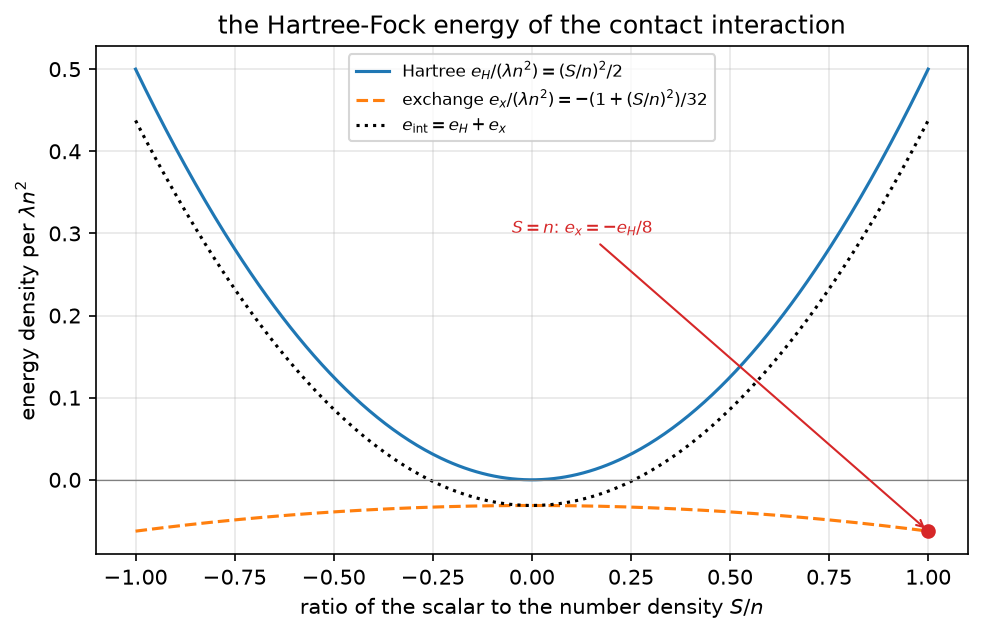

Figure 14d.2 saved as Revision/textbook/figures/14d_2_energy_densities.png


In [9]:
s_over_n = np.linspace(-1.0, 1.0, 401)
hartree = 0.5 * s_over_n ** 2
exchange_curve = -(1.0 + s_over_n ** 2) / 32.0
fig, ax = plt.subplots(figsize=(7.5, 4.4))
ax.plot(s_over_n, hartree, label="Hartree $e_H/(\\lambda n^2) = (S/n)^2/2$")
ax.plot(s_over_n, exchange_curve, "--",
        label="exchange $e_x/(\\lambda n^2) = -(1 + (S/n)^2)/32$")
ax.plot(s_over_n, hartree + exchange_curve, ":", color="black",
        label="$e_{\\rm int} = e_H + e_x$")
ax.plot([1.0], [-1.0 / 16.0], "o", color="C3")
ax.annotate("$S = n$: $e_x = -e_H/8$", xy=(1.0, -1.0 / 16.0), xytext=(-0.05, 0.3),
            fontsize=8, color="C3", arrowprops={"arrowstyle": "->", "color": "C3"})
ax.axhline(0.0, color="gray", linewidth=0.6)
ax.set_xlabel("ratio of the scalar to the number density $S/n$")
ax.set_ylabel("energy density per $\\lambda n^2$")
ax.set_title("the Hartree-Fock energy of the contact interaction")
ax.legend(fontsize=8, loc="upper center")
save_figure(fig, "energy_densities",
            "The interaction energy densities of the contact term per unit "
            "$\\lambda n^2$ against the ratio $S/n$ of the scalar and the number "
            "density: the Hartree term $(S/n)^2/2$ (solid), the exact local "
            "exchange $-(1 + (S/n)^2)/32$ (dashed) and their sum $e_{\\rm int}$ "
            "(dotted). For $\\lambda > 0$ the exchange lowers the energy a little; "
            "at $S = n$ (a filled level at rest, red dot) it is $-1/8$ of the "
            "Hartree term, and near $S = 0$ it is all that is left.")

## 11. The exact Fock exchange of the closed-shell slab

The states of the model are not uniform along $y$, and in each block the
orbital is a $2\times2$ object. The Revision record computes the EXACT Fock
exchange of such a closed-shell state: take one level with the $2\times2$ block
density $D = \frac12(d_0 + d_1\sigma_1 + d_2\sigma_2 + d_3\sigma_3)$ in each of
the four blocks of type $j = +1$ and $\sigma_3D\sigma_3$ in each of the four of
type $-1$ (the degenerate partners), and average it over a closed shell of
3-space directions; the average is the projection onto the commutant of the
3-space rotations (the 64-dimensional space of matrices that commute with
$\gamma^{(x_1)}\gamma^{(x_2)}$, $\gamma^{(x_1)}\gamma^{(x_3)}$,
$\gamma^{(x_2)}\gamma^{(x_3)}$). The result: $n = 8d_0$, $S = 8d_2$,
$Q = \langle\Psi^\dagger B\gamma^{(x_8)}\Psi\rangle = 8d_3$, the $y$-current
$Y = 8d_1$, and

$$e_x^{\rm exact} = -\frac{\lambda}{32}(n^2 + S^2 - Q^2 - Y^2).$$

For eigen-orbitals $Y = 0$; so the uniform-gas exchange omits $+\frac{\lambda}{32}
Q^2$. The canonical functional of the Revision theory is the uniform-gas one; the
exact Fock exchange is a DIAGNOSTIC that the Rust solver reports and also solves
as a variant. The next cell repeats the computation: it reads the block basis
from the Revision record (and checks that it is unitary), builds the averaged
one-body matrix with sympy's linear solver and checks the four densities and the
exchange.

In [10]:
as_number = {"0": 0, "1": 1, "-1": -1, "I": sp.I, "-I": -sp.I}
U = sp.Matrix([[as_number[e] for e in row] for row in
               theory["blockBasis"]["unnormalisedColumns2Sqrt2V"]])
V = U / (2 * sp.sqrt(2))  # the block basis of the record
labels = [(j, s2, s3) for j in (1, -1) for s2 in (1, -1) for s3 in (1, -1)]
s1 = sp.Matrix([[0, 1], [1, 0]])
s2m = sp.Matrix([[0, -sp.I], [sp.I, 0]])
s3 = sp.Matrix([[1, 0], [0, -1]])
d0, d1, d2, d3 = sp.symbols("d0 d1 d2 d3", real=True)
D = (d0 * sp.eye(2) + d1 * s1 + d2 * s2m + d3 * s3) / 2  # the block density
G_slab = Z16
for b, (j, _, _) in enumerate(labels):
    Vb = V[:, 2 * b:2 * b + 2]
    G_slab = G_slab + Vb * (D if j == 1 else s3 * D * s3) * Vb.H
unknowns = sp.Matrix(16, 16, sp.symbols("x0:256"))  # a general 16 x 16 matrix
equations = []
for rotation in (g1 * g2, g1 * g3, g2 * g3):  # commute with the 3-space rotations
    equations += list(rotation * unknowns - unknowns * rotation)
solution = sp.Matrix(16, 16, list(list(sp.linsolve(equations, list(unknowns)))[0]))
free = sorted(solution.free_symbols, key=lambda s_: int(str(s_)[1:]))
basis = [solution.subs({x: (1 if x == y else 0) for x in free}) for y in free]
gram = sp.Matrix(len(basis), len(basis),
                 lambda i, k: (basis[i].H * basis[k]).trace())
coefficients = gram.LUsolve(sp.Matrix([(b_.H * G_slab).trace() for b_ in basis]))
G_avg = sp.simplify(sum((c_ * b_ for c_, b_ in zip(coefficients, basis)), Z16))
rho_slab = G_avg * B
n_s, S_s = sp.simplify((B * rho_slab).trace()), sp.simplify((C * rho_slab).trace())
Q_s = sp.simplify((B * g8 * rho_slab).trace())
e_x_slab = sp.expand(-lam / 2 * (C * rho_slab * C * rho_slab).trace())
say(f"commutant dimension {len(basis)}; n = {n_s}, S = {S_s}, Q = {Q_s}")
say(f"V unitary: {sp.simplify(V.H * V) == I16}")
check(len(basis) == 64 and n_s == 8 * d0 and S_s == 8 * d2 and Q_s == 8 * d3
      and sp.simplify(e_x_slab + lam / 32 * (n_s ** 2 + S_s ** 2 - Q_s ** 2
                                             - (8 * d1) ** 2)) == 0
      and record_check("exchange_slab_exact_fock"),
      "exact Fock exchange of the slab: -(lambda/32)(n^2 + S^2 - Q^2 - Y^2)",
      record=f"{PY_REPORT}, check exchange_slab_exact_fock")

commutant dimension 64; n = 8*d0, S = 8*d2, Q = 8*d3
V unitary: True
PASS exact Fock exchange of the slab: -(lambda/32)(n^2 + S^2 - Q^2 - Y^2)
     reproduces Revision/kohn_sham/reports/ks-theory-python.json, check
    exchange_slab_exact_fock


For one orbital $\chi = (a, ib)$ the three densities are proportional to
$a^2 + b^2$ ($n$), $2ab$ ($S$, up to the sign $j$) and $a^2 - b^2$ ($Q$), so
$S^2 + Q^2 = n^2$; for a mixture $S^2 + Q^2 \le n^2$: the physical states fill
the disk $(S/n)^2 + (Q/n)^2 \le 1$. The next cell draws, over this disk, the
ratio $e_x^{\rm exact}/e_x^{\rm gas} = (n^2 + S^2 - Q^2)/(n^2 + S^2)$ of the exact
Fock exchange to the uniform-gas exchange ($Y = 0$). On the line $Q = 0$ the two
agree; at the point $S = 0$, $Q = n$, which is the state of the zero modes
(section 12), the exact exchange vanishes.

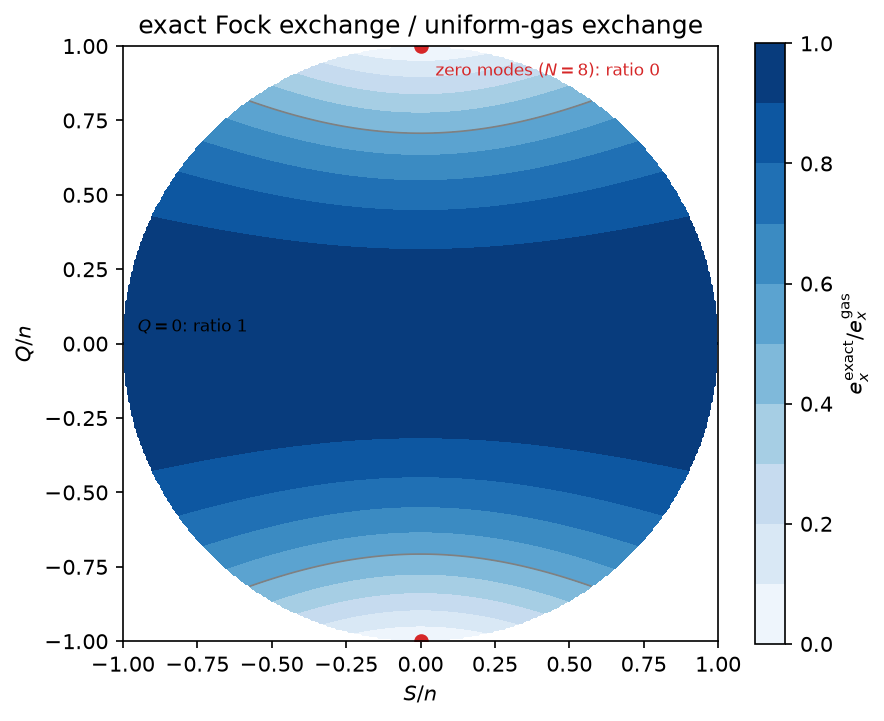

Figure 14d.3 saved as Revision/textbook/figures/14d_3_exact_fock_ratio.png


In [11]:
grid = np.linspace(-1.0, 1.0, 401)
S_grid, Q_grid = np.meshgrid(grid, grid)  # S/n horizontally, Q/n vertically
inside = S_grid ** 2 + Q_grid ** 2 <= 1.0
ratio_grid = np.where(inside, (1.0 + S_grid ** 2 - Q_grid ** 2) / (1.0 + S_grid ** 2),
                      np.nan)
fig, ax = plt.subplots(figsize=(6.4, 5.2))
filled = ax.contourf(S_grid, Q_grid, ratio_grid, levels=np.linspace(0.0, 1.0, 11),
                     cmap="Blues")
ax.contour(S_grid, Q_grid, ratio_grid, levels=[0.5], colors="gray", linewidths=0.8)
fig.colorbar(filled, ax=ax, label="$e_x^{\\rm exact} / e_x^{\\rm gas}$")
ax.plot([0.0, 0.0], [1.0, -1.0], "o", color="C3")  # S = 0, Q = +n and -n
ax.annotate("zero modes ($N = 8$): ratio 0", (0.05, 0.9), fontsize=8, color="C3")
ax.annotate("$Q = 0$: ratio 1", (-0.95, 0.04), fontsize=8)
ax.set_xlabel("$S/n$")
ax.set_ylabel("$Q/n$")
ax.set_aspect("equal")
ax.grid(False)
ax.set_title("exact Fock exchange / uniform-gas exchange")
save_figure(fig, "exact_fock_ratio",
            "The ratio of the exact Fock exchange of a closed-shell slab state, "
            "$-(\\lambda/32)(n^2 + S^2 - Q^2)$, to the uniform-gas exchange "
            "$-(\\lambda/32)(n^2 + S^2)$, over the disk of possible density "
            "ratios $(S/n)^2 + (Q/n)^2 \\le 1$ (horizontal $S/n$, vertical "
            "$Q/n$, darker is larger, gray line the ratio 1/2). On the line "
            "$Q = 0$ the two exchanges agree; toward the top and bottom of the "
            "disk the uniform-gas formula overestimates the exchange, and at "
            "$S = 0$, $Q = \\pm n$ (red dots; the top one is the state of the "
            "eight zero modes) the exact exchange vanishes.")

## 12. The state of the eight zero modes (N = 8)

The simplest Kohn-Sham state of the model fills the eight brane zero modes at
$k = 0$ (both block types, even parity). Each orbital is $\chi = (a, 0)$ with
$a = \sqrt{2M/(1 - e^{-2ML})}\,e^{My}$ (normalised on the patch). The densities,
line by line (Revision record, `densities`):

1. One orbital: $n_o = P\,(a^2 + b^2) = Pa^2$, $s_o = P\,j\,2ab = 0$,
   $q_o = P\,(a^2 - b^2) = Pa^2$, with $P = e^{-6Hy}/(\ell^3v_t)$ (the factor
   that makes the densities proper).
2. The state: $n = \sum w\,g\,f\,n_o$ with the weight $w = \frac12$ of the
   ASSUMED Z2 doubled system, the degeneracy $g = 4$ per block type and $f = 1$:
   $n = \frac12(4 + 4)Pa^2 = 4Pa^2$; $S = 0$; $Q = n$.
3. The potentials to first order in $\lambda$ (free orbitals):
   $M_{\rm eff} - m = \frac{15}{16}\lambda S = 0$, $v_v = -\frac{\lambda}{16}n$.
4. The Revision solver calibrates its couplings by the largest first-order
   potential per unit $\lambda$, max over $y$ of $\max(\frac{15}{16}|S|,
   |n|/16)$, here $n_{\max}/16$; $\lambda_1$ and $\lambda_2$ are $0.1$ and $0.3$
   divided by it, rounded to 4 significant digits.
5. Exact Fock exchange: with $S = 0$ and $Q = n$, $e_x^{\rm exact} =
   -\frac{\lambda}{32}(n^2 - Q^2) = 0$. In the exact-Fock functional the
   potential is $v_v + w_Q\sigma_3$ with $w_Q = \frac{\lambda}{16}Q$, which on
   $(a, 0)$ acts as $\frac{\lambda}{16}(Q - n) = 0$: the zero modes stay exact
   solutions with $\varepsilon = 0$ and the energy of the state is exactly 0.

With $H = m = 1$, $L = 3$, $\ell = 2\pi/0.25$, $v_t = 1$, the next cell computes
$n(y)$ and its maximum (at the tip $y = -3$, where $e^{-6Hy}a^2 \propto
e^{(2M - 6H)y}$ is largest) and compares with the records: the largest proper
density of the free state $N = 8$ (`ground/summary.csv`, column `n_max`), the
strength per $\lambda$, $\lambda_{1,2}$ and the first-order potentials
(`parameters.json`), and the self-consistent exact-Fock energies of all twenty
$N = 8$ states (`exx/exact-fock-variant.csv`), which must be zero to rounding.

In [12]:
H_val, m_val, L_val = 1.0, 1.0, 3.0
ell = 2.0 * math.pi / 0.25  # the coordinate size of the 3-torus
vol7 = ell ** 3 * 1.0  # the coordinate 7-volume ell^3 v_t
y = np.linspace(-L_val, 0.0, 1801)  # the hidden coordinate
a_sq = 2.0 * m_val / (1.0 - math.exp(-2.0 * m_val * L_val)) * np.exp(2.0 * m_val * y)
P = np.exp(-6.0 * H_val * y) / vol7  # proper-density factor
n_y = 4.0 * P * a_sq  # line 2
n_max = float(np.max(n_y))
summary = repository_file("Revision/kohn_sham/results/ground/summary.csv") \
    .read_text(encoding="utf-8").splitlines()
header = summary[0].split(",")
free8 = dict(zip(header, [r for r in summary if r.startswith("N8_lam0_a00,")][0]
                 .split(",")))
report("largest proper density of the free N = 8 state", f"{n_max:.10f}",
       "per unit proper 7-volume")
check(abs(n_max / float(free8["n_max"]) - 1.0) < 1e-9 and float(y[np.argmax(n_y)])
      == -3.0,
      "n_max = 4 P a^2 at the tip y = -3 equals the record",
      record="Revision/kohn_sham/results/ground/summary.csv, N8_lam0_a00, n_max")


def round_significant(x, digits):
    """x rounded to digits significant digits (halves away from zero)."""
    exponent = math.floor(math.log10(abs(x))) - (digits - 1)
    scale = 10.0 ** (-exponent)
    return math.copysign(math.floor(abs(x) * scale + 0.5), x) / scale


strength = n_max / 16.0  # line 4: the largest first-order potential per lambda
lambda_1 = round_significant(0.1 / strength, 4)
lambda_2 = round_significant(0.3 / strength, 4)
parameters = json.loads(repository_file("Revision/kohn_sham/results/parameters.json")
                        .read_text(encoding="utf-8"))
calibration = [c for c in parameters["couplingCalibration"]["values"]
               if c["N"] == 8.0][0]
report("strength per lambda", f"{strength:.9f}")
report("lambda_1, lambda_2", f"{lambda_1}, {lambda_2}")
report("first-order potentials", f"{lambda_1 * strength:.10f}, "
       f"{lambda_2 * strength:.10f}", "m")
check(abs(strength / calibration["strengthPerLambda"] - 1.0) < 1e-9
      and lambda_1 == calibration["lambda1"] and lambda_2 == calibration["lambda2"]
      and abs(lambda_1 * strength - calibration["firstOrderPotential1"]) < 1e-9
      and len(set(calibration["strengthPerLambdaAtSlices"])) == 1,
      "strength 5.1388, lambda_1 = 0.01946, lambda_2 = 0.05838 (the same at all "
      "slices)", record="Revision/kohn_sham/results/parameters.json, "
      "couplingCalibration N = 8")
exx = repository_file("Revision/kohn_sham/results/exx/exact-fock-variant.csv") \
    .read_text(encoding="utf-8").splitlines()
exx_header = exx[0].split(",")
rows8 = [dict(zip(exx_header, r.split(","))) for r in exx[1:] if r.startswith("N8_")]
largest = max(abs(float(r["E_exact_fock_scf"])) for r in rows8)
check(len(rows8) == 20 and largest < 1e-12,
      "the self-consistent exact-Fock energy of all 20 N = 8 states is 0",
      record="Revision/kohn_sham/results/exx/exact-fock-variant.csv, "
             "E_exact_fock_scf")

RESULT largest proper density of the free N = 8 state = 82.2208638894 per unit proper
    7-volume
PASS n_max = 4 P a^2 at the tip y = -3 equals the record
     reproduces Revision/kohn_sham/results/ground/summary.csv, N8_lam0_a00, n_max
RESULT strength per lambda = 5.138803993
RESULT lambda_1, lambda_2 = 0.01946, 0.05838
RESULT first-order potentials = 0.1000011257, 0.3000033771 m
PASS strength 5.1388, lambda_1 = 0.01946, lambda_2 = 0.05838 (the same at all slices)
     reproduces Revision/kohn_sham/results/parameters.json, couplingCalibration N = 8
PASS the self-consistent exact-Fock energy of all 20 N = 8 states is 0
     reproduces Revision/kohn_sham/results/exx/exact-fock-variant.csv, E_exact_fock_scf


The next cell draws the state. Left: the proper density $n(y)$ and the
coordinate density $e^{6Hy}n(y)$ (particles per unit $y$ and per unit coordinate
volume) on a logarithmic axis: the zero modes sit at the brane in the coordinate
density, but because the proper 7-volume $e^{6Hy}$ shrinks toward the tip, the
PROPER density, which the interaction feels, is largest at the tip. Right: the
first-order vector potential $v_v = -\lambda n/16$ of the uniform-gas
functional for $\lambda_1$ and $\lambda_2$ (its largest size is $0.1$ and
$0.3\,m$, by the calibration) and the exact-Fock combination
$v_v + w_Q = \frac{\lambda}{16}(Q - n) = 0$.

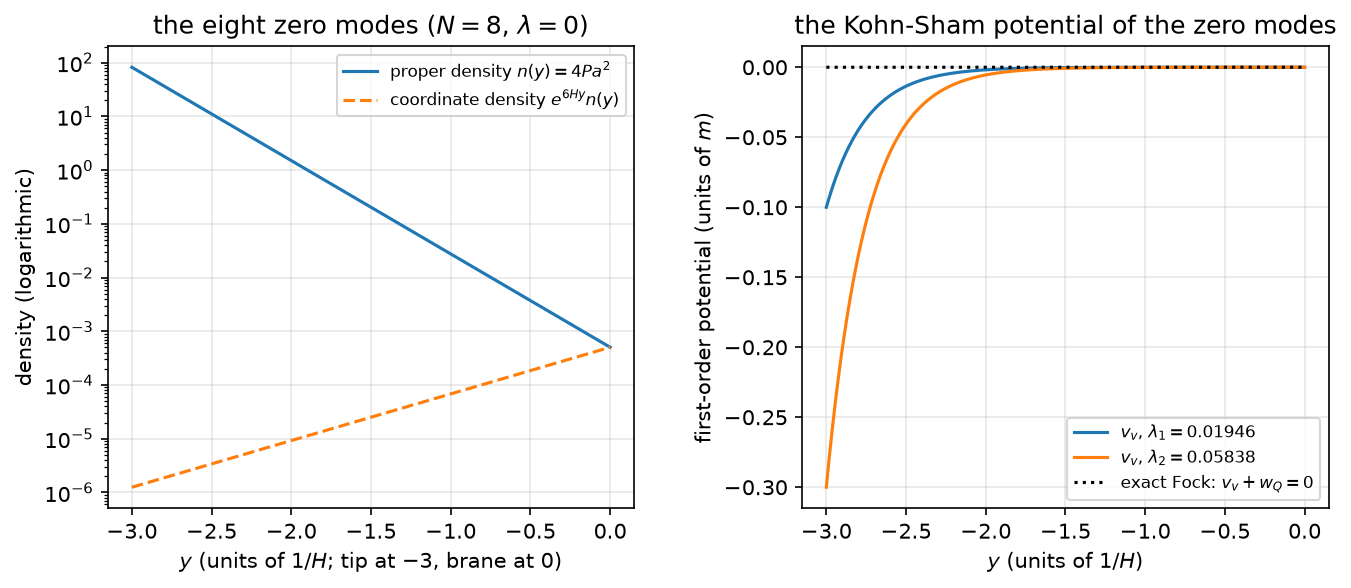

Figure 14d.4 saved as Revision/textbook/figures/14d_4_zero_mode_state.png


In [13]:
fig, (left, right) = plt.subplots(1, 2, figsize=(10.5, 4.0))
fig.subplots_adjust(wspace=0.32)  # room for the label of the right panel
left.semilogy(y, n_y, label="proper density $n(y) = 4Pa^2$")
left.semilogy(y, np.exp(6.0 * y) * n_y, "--",
              label="coordinate density $e^{6Hy} n(y)$")
left.set_xlabel("$y$ (units of $1/H$; tip at $-3$, brane at $0$)")
left.set_ylabel("density (logarithmic)")
left.set_title("the eight zero modes ($N = 8$, $\\lambda = 0$)")
left.legend(fontsize=8)
right.plot(y, -lambda_1 * n_y / 16.0, label=f"$v_v$, $\\lambda_1 = {lambda_1}$")
right.plot(y, -lambda_2 * n_y / 16.0, label=f"$v_v$, $\\lambda_2 = {lambda_2}$")
right.plot(y, np.zeros_like(y), ":", color="black",
           label="exact Fock: $v_v + w_Q = 0$")
right.set_xlabel("$y$ (units of $1/H$)")
right.set_ylabel("first-order potential (units of $m$)")
right.set_title("the Kohn-Sham potential of the zero modes")
right.legend(fontsize=8, loc="lower right")
save_figure(fig, "zero_mode_state",
            "The state of the eight brane zero modes ($N = 8$, $m = H = 1$, "
            "$L = 3$, $\\Delta k = 0.25$, $v_t = 1$). Left, logarithmic axis: the "
            "proper density $n(y) = 4Pa^2$ (solid) and the coordinate density "
            "$e^{6Hy}n(y)$ (dashed) against $y$ (units of $1/H$); the orbitals "
            "sit at the brane, but the proper density is largest at the tip, "
            "$n_{\\max} = 82.22$ at $y = -3$. Right: the first-order vector "
            "potential $v_v = -\\lambda n/16$ of the uniform-gas functional for "
            "$\\lambda_1 = 0.01946$ and $\\lambda_2 = 0.05838$ (lowest values "
            "$-0.1$ and $-0.3$ in units of $m$, the calibration of the Revision "
            "runs) and the exact-Fock potential, which is zero for this state.")

## 13. The last check

The last cell checks that the four figure files exist and prints the number of
checks that passed.

In [14]:
figure_names = ["14d_1_pair_average.png", "14d_2_energy_densities.png",
                "14d_3_exact_fock_ratio.png", "14d_4_zero_mode_state.png"]
check(all(output_file(f"{FIGURE_FOLDER}/{name}").is_file() for name in figure_names),
      "all four figure files of this notebook exist")
all_checks_passed()

PASS all four figure files of this notebook exist
ALL 16 CHECKS PASSED (notebook 14d)


## 14. What this notebook showed

- The flat good-sector plane waves have the energies $\pm\sqrt{M^2 + p^2}$, each
  8 times; every occupation symmetric under $\mathbf p \to -\mathbf p$ has the
  one-body matrix $\rho = (nB + SC)/16$ (PROVED).
- Wick's rule gives $\langle{:}S^2{:}\rangle = (\mathrm{Tr}\,C\rho)^2 -
  \mathrm{Tr}(C\rho C\rho)$, and the exchange of the contact interaction is
  exactly local: $e_x = -\frac{\lambda}{32}(n^2 + S^2)$ at every temperature;
  a filled level at rest has $e_x/e_H = -1/8$ (PROVED).
- The Kohn-Sham potentials are $M_{\rm eff} = m + \frac{15}{16}\lambda S$ and
  $v_v = -\frac{\lambda}{16}n$; on shell $\langle L\rangle/\sqrt{|g|} =
  e_{\rm int}$ (PROVED; the coefficients equal those the Rust solver used).
- For the closed-shell slab states the exact Fock exchange is
  $-\frac{\lambda}{32}(n^2 + S^2 - Q^2 - Y^2)$; the canonical (uniform-gas)
  functional omits $+\frac{\lambda}{32}Q^2$ (PROVED; a DIAGNOSTIC of the
  functional; there is no correlation energy in either).
- The eight zero modes have $S = 0$ and $Q = n$; their proper density is largest
  at the tip ($n_{\max} = 82.22$); this fixes the Revision couplings
  $\lambda_1 = 0.01946$, $\lambda_2 = 0.05838$ for $N = 8$; and their exact Fock
  exchange vanishes, so their exact-Fock energy is exactly zero (the record's
  self-consistent values are zero to rounding).
- ASSUMED: the Z2 doubled system (the weight $w = \frac12$) and the good sector.